### Plant Biosignal Classification Pipeline

**Dataset**: Holy Basil   
**Models**: Logistic Regression, Random Forest, Gradient Boosting, SVM, XGBoost, Naive Bayes  
**Goal**: Binary classification (Touch vs. No Touch)

---

## 1. Setup and Imports

In [1]:
# Standard libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import wavfile
from scipy import signal
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Try importing XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost not available. Install with: pip install xgboost")

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ All libraries imported successfully")

✓ XGBoost available
✓ All libraries imported successfully


## 2. Configuration

In [2]:
# Paths
DATA_DIR = r"dataset/holy basil"
METADATA_FILE = os.path.join(DATA_DIR, "metadata.csv")
OUTPUT_DIR = "output"
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")

# Create output directories
os.makedirs(MODELS_DIR, exist_ok=True)

# Signal processing parameters
WINDOW_SIZE = 5.0  # seconds
HOP_SIZE = 0.5     # seconds (not used for training, but for reference)
TARGET_SR = 10000  # Hz

# Feature names (in order)
FEATURE_NAMES = ['rms', 'peak_to_peak', 'std', 'percentile_90', 'mean_abs']

print(f"✓ Configuration set")
print(f"  Data directory: {DATA_DIR}")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Window size: {WINDOW_SIZE}s")
print(f"  Target sample rate: {TARGET_SR} Hz")

✓ Configuration set
  Data directory: dataset/holy basil
  Output directory: output
  Window size: 5.0s
  Target sample rate: 10000 Hz


## 3. Data Loading Functions
    - Centers signal around zero
    - Removes baseline drift

In [3]:
def load_and_preprocess_audio(filepath):
    """
    Load WAV file and apply minimal preprocessing. This normalizes recordings from different branches. (mean changes from values like 0.000123 -> 0.0000001, which is more consistent across recordings)
    
    Steps:
    1. Load WAV (int16)
    2. Convert to float32 [-1, 1]
    3. Handle stereo -> mono
    4. DC removal (center at zero)
    
    Returns:
        sr: Sample rate (Hz)
        audio: Preprocessed audio array (float32)
    """
    # Load WAV file
    sr, audio = wavfile.read(filepath)
    
    # Convert to float
    if audio.dtype == np.int16:
        audio = audio.astype(np.float32) / 32768.0
    elif audio.dtype == np.int32:
        audio = audio.astype(np.float32) / 2147483648.0
    
    # Handle stereo -> mono
    if len(audio.shape) > 1:
        audio = np.mean(audio, axis=1)
    
    # DC offset removal (center signal at zero)
    audio = audio - np.mean(audio)
    
    return sr, audio


def extract_features(window):
    """
    Extract 5 statistical features from audio window
    
    Features:
    1. RMS (Root Mean Square) - signal energy
    2. Peak-to-Peak - amplitude range (Maximum signall swing)
    3. Standard Deviation - variability
    4. 90th Percentile - upper amplitude
    5. Mean Absolute Value - average magnitude
    
    Returns:
        dict: Feature name -> value
    """
    features = {}
    features['rms'] = np.sqrt(np.mean(window**2))
    features['peak_to_peak'] = np.ptp(window)
    features['std'] = np.std(window)
    features['percentile_90'] = np.percentile(np.abs(window), 90)
    features['mean_abs'] = np.mean(np.abs(window))
    
    return features


print("✓ Data loading functions defined")

✓ Data loading functions defined


## 4. Load Metadata and Inspect Dataset

In [16]:
# Load metadata
metadata = pd.read_csv(METADATA_FILE)

print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"\nTotal recordings: {len(metadata)}")
print(f"\nClass distribution:")
print(metadata['label'].value_counts())
print(f"  • Class 0 (No Touch): {sum(metadata['label'] == 0)} recordings")
print(f"  • Class 1 (Touch): {sum(metadata['label'] == 1)} recordings")

if 'touch_group' in metadata.columns:
    print(f"\nTouch groups:")
    print(metadata[metadata['label'] == 1]['touch_group'].value_counts())

print("\nFirst 5 rows:")
display(metadata.sample(5))

print("="*70)

DATASET OVERVIEW

Total recordings: 45

Class distribution:
label
1    30
0    15
Name: count, dtype: int64
  • Class 0 (No Touch): 15 recordings
  • Class 1 (Touch): 30 recordings

Touch groups:
touch_group
early        10
mid_early    10
mid_late     10
Name: count, dtype: int64

First 5 rows:


,recording_id,filename,label,touch_time_sec,touch_group,notes
22,23,touch_08.wav,1,17.0,early,NaN
0,1,control_01.wav,0,NaN,control,NaN
26,27,touch_12.wav,1,27.0,mid_early,NaN
4,5,control_05.wav,0,NaN,control,NaN
32,33,touch_18.wav,1,30.0,mid_early,NaN


## 5. Window Extraction and Feature Extraction

In [26]:
print("Starting window extraction and feature extraction...\n")

X_list = []  # Features
y_list = []  # Labels
recording_info = []  # Track which recording each window came from

for idx, row in metadata.iterrows():
    filepath = os.path.join(DATA_DIR, row['filename'])
    
    if not os.path.exists(filepath):
        print(f"⚠️ File not found: {filepath}")
        continue
    
    try:
        # Load audio
        sr, audio = load_and_preprocess_audio(filepath)
        
        window_samples = int(WINDOW_SIZE * sr)
        
        if row['label'] == 1:  # Touch recording
            # Extract 2 windows: touch window + baseline window
            
            # Window 1: Touch window (centered on touch time) e.g., if touch_time = 16s, and window_size = 5s, we take from 13.5s to 18.5s
            touch_time = row['touch_time_sec']
            center_sample = int(touch_time * sr)
            start_sample = center_sample - window_samples // 2
            end_sample = start_sample + window_samples
            
            if start_sample >= 0 and end_sample <= len(audio):
                touch_window = audio[start_sample:end_sample]
                features = extract_features(touch_window)
                X_list.append([features[f] for f in FEATURE_NAMES])
                y_list.append(1)  # Touch
                recording_info.append(f"{row['filename']}_touch")
            
            # Window 2: Baseline window (before touch) e,g.: if touch_time = 16s, we take from 6s to 11s (10 seconds before touch)
            baseline_start = start_sample - int(10 * sr)  # 10 seconds before touch
            baseline_end = baseline_start + window_samples
            
            if baseline_start >= 0 and baseline_end <= len(audio):
                baseline_window = audio[baseline_start:baseline_end]
                features = extract_features(baseline_window)
                X_list.append([features[f] for f in FEATURE_NAMES])
                y_list.append(0)  # No touch
                recording_info.append(f"{row['filename']}_baseline")
        
        else:  # Control recording (label == 0)
            # Extract 3 random windows
            for i in range(3):
                max_start = len(audio) - window_samples - int(5 * sr)  # Keep away from edges
                if max_start > int(5 * sr):
                    start_sample = np.random.randint(int(5 * sr), max_start)
                    window = audio[start_sample:start_sample + window_samples]
                    
                    features = extract_features(window)
                    X_list.append([features[f] for f in FEATURE_NAMES])
                    y_list.append(0)  # No touch
                    recording_info.append(f"{row['filename']}_control_{i+1}")
        
        if (idx + 1) % 5 == 0:
            print(f"  Processed {idx + 1}/{len(metadata)} files...")
    
    except Exception as e:
        print(f"❌ Error processing {row['filename']}: {e}")
        continue

# Convert to numpy arrays
X = np.array(X_list)
y = np.array(y_list)

print(f"\n{'='*70}")
print("FEATURE EXTRACTION COMPLETE")
print(f"{'='*70}")
print(f"Total windows extracted: {len(X)}")
print(f"  • No Touch (class 0): {sum(y == 0)} windows")
print("         - 3 random windows extracted from each control recording")
print("         - For a 60 sec recording, we can extract 3 windows: e.g., from 8s-13s, 22s-27s, 41s-46s (keeping away from edges)")
print(f"  • Touch (class 1): {sum(y == 1)} windows")
print("         - 2 windows extracted from each touch recording: 1 touch window + 1 baseline window")
print("         - Window 1: Touch window (centered on touch time) e.g., if touch_time = 16s, and window_size = 5s, we take from 13.5s to 18.5s")
print("         - Window 2: Baseline window (before touch) e,g.: if touch_time = 16s, we take from 6s to 11s (10 seconds before touch)")

print("Touch Signal = 30 recordings x 2 windows each = 60 windows")
print("Control Signal = 15 recordings x 3 windows = 45 windows")
print("Total = 105 windows")

print(f"\nFeature matrix shape: {X.shape}")
print(f"Label array shape: {y.shape}")
print(f"\nFeatures: {FEATURE_NAMES}")
print(f"{'='*70}\n")

Starting window extraction and feature extraction...

  Processed 5/45 files...
  Processed 10/45 files...
  Processed 15/45 files...
  Processed 20/45 files...
  Processed 25/45 files...
  Processed 30/45 files...
  Processed 35/45 files...
  Processed 40/45 files...
  Processed 45/45 files...

FEATURE EXTRACTION COMPLETE
Total windows extracted: 105
  • No Touch (class 0): 75 windows
         - 3 random windows extracted from each control recording
         - For a 60 sec recording, we can extract 3 windows: e.g., from 8s-13s, 22s-27s, 41s-46s (keeping away from edges)
  • Touch (class 1): 30 windows
         - 2 windows extracted from each touch recording: 1 touch window + 1 baseline window
         - Window 1: Touch window (centered on touch time) e.g., if touch_time = 16s, and window_size = 5s, we take from 13.5s to 18.5s
         - Window 2: Baseline window (before touch) e,g.: if touch_time = 16s, we take from 6s to 11s (10 seconds before touch)
Touch Signal = 30 recordings x 2 

## 6. Feature Analysis and Visualization

In [6]:
# Create DataFrame for easier analysis
feature_df = pd.DataFrame(X, columns=FEATURE_NAMES)
feature_df['label'] = y
feature_df['class'] = feature_df['label'].map({0: 'No Touch', 1: 'Touch'})

print("Feature Statistics by Class:\n")
print(feature_df.groupby('class')[FEATURE_NAMES].agg(['mean', 'std']))

# Calculate separation ratios
print("\n" + "="*70)
print("FEATURE SEPARATION ANALYSIS")
print("="*70)
for feature in FEATURE_NAMES:
    no_touch_mean = feature_df[feature_df['label'] == 0][feature].mean()
    touch_mean = feature_df[feature_df['label'] == 1][feature].mean()
    ratio = touch_mean / no_touch_mean if no_touch_mean > 0 else 0
    print(f"{feature:20s}: {ratio:.2f}x (Touch/No-Touch)")
print("="*70)

Feature Statistics by Class:

               rms           peak_to_peak                 std            \
              mean       std         mean       std      mean       std   
class                                                                     
No Touch  0.000135  0.000277     0.000368  0.000546  0.000085  0.000170   
Touch     0.002550  0.002221     0.020458  0.020188  0.002506  0.002237   

         percentile_90            mean_abs            
                  mean       std      mean       std  
class                                                 
No Touch      0.000211  0.000445  0.000116  0.000243  
Touch         0.001372  0.000922  0.000922  0.000597  

FEATURE SEPARATION ANALYSIS
rms                 : 18.83x (Touch/No-Touch)
peak_to_peak        : 55.56x (Touch/No-Touch)
std                 : 29.53x (Touch/No-Touch)
percentile_90       : 6.50x (Touch/No-Touch)
mean_abs            : 7.94x (Touch/No-Touch)


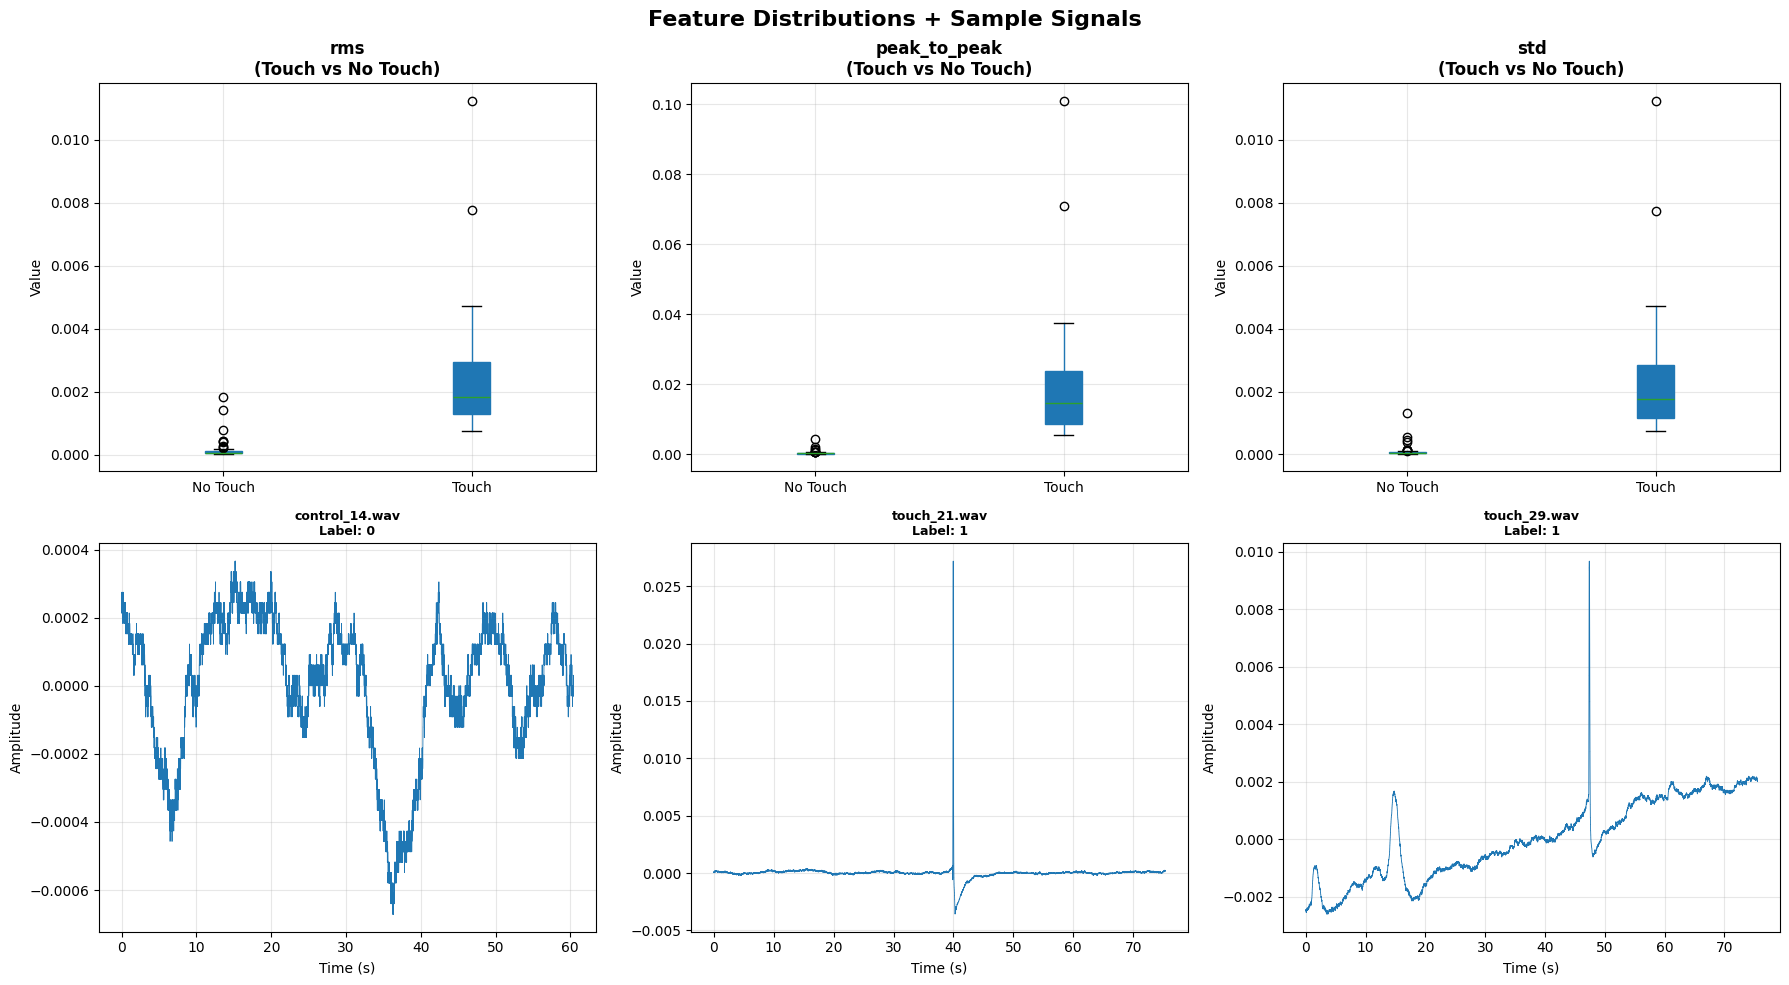

In [ ]:
# 3 features with notable importance in predictions (based on feature importance analysis from models like Random Forest and XGBoost)
selected_features = ['rms', 'peak_to_peak', 'std']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Visualizze feature distributions
for idx, feature in enumerate(selected_features):
    ax = axes[idx]
    feature_df.boxplot(column=feature, by='class',
                       ax=ax, patch_artist=True)
    ax.set_title(f'{feature}\n(Touch vs No Touch)', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

# Visualizing control and touch plots
def load_and_preprocess(filepath):
    sr, audio = wavfile.read(filepath)
    if audio.dtype == np.int16:
        audio = audio.astype(np.float32) / 32768.0
    if len(audio.shape) > 1:
        audio = np.mean(audio, axis=1)
    audio = audio - np.mean(audio)
    return sr, audio


# Randomly select recordings
random_rows = metadata.sample(3)
for i, (_, row) in enumerate(random_rows.iterrows()):
    ax = axes[i + 3]
    filepath = os.path.join(DATA_DIR, row['filename'])
    try:
        sr, audio = load_and_preprocess(filepath)
        time = np.arange(len(audio)) / sr
        
        ax.plot(time, audio, linewidth=0.6)
        ax.set_title(f"{row['filename']}\nLabel: {row['label']}",
                     fontsize=9, fontweight='bold')
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude")
        ax.grid(True, alpha=0.3)
    except Exception as e:
        ax.text(0.5, 0.5, f"Error loading\n{row['filename']}",
                ha='center', va='center')

plt.suptitle("Feature Distributions + Sample Signals",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Scaling

In [8]:
# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature Scaling Applied:\n")
print(f"Original feature ranges:")
for i, feature in enumerate(FEATURE_NAMES):
    print(f"  {feature:20s}: [{X[:, i].min():.6f}, {X[:, i].max():.6f}]")

print(f"\nScaled feature ranges:")
for i, feature in enumerate(FEATURE_NAMES):
    print(f"  {feature:20s}: [{X_scaled[:, i].min():.6f}, {X_scaled[:, i].max():.6f}]")

print(f"\n✓ Features scaled using StandardScaler")
print(f"  Mean: {X_scaled.mean(axis=0)}")
print(f"  Std: {X_scaled.std(axis=0)}")

Feature Scaling Applied:

Original feature ranges:
  rms                 : [0.000024, 0.011245]
  peak_to_peak        : [0.000122, 0.100922]
  std                 : [0.000023, 0.011236]
  percentile_90       : [0.000031, 0.004688]
  mean_abs            : [0.000019, 0.003156]

Scaled feature ranges:
  rms                 : [-0.496361, 6.454681]
  peak_to_peak        : [-0.428518, 6.787269]
  std                 : [-0.467534, 6.487940]
  percentile_90       : [-0.635509, 5.145055]
  mean_abs            : [-0.627547, 5.380804]

✓ Features scaled using StandardScaler
  Mean: [-6.87280920e-18 -2.80199144e-17 -1.32169408e-17 -7.87729670e-17
 -1.02299122e-16]
  Std: [1. 1. 1. 1. 1.]


## 8. Model Training - All 6 Algorithms

In [9]:
print("="*70)
print("TRAINING ALL MODELS")
print("="*70)
print(f"\nTraining data: {len(X_scaled)} samples")
print(f"  • Class 0: {sum(y == 0)} samples")
print(f"  • Class 1: {sum(y == 1)} samples")
print(f"\nStarting training...\n")

models = {}
training_times = {}

# 1. Logistic Regression
print("1/6: Training Logistic Regression...")
start_time = datetime.now()
models['logistic_regression'] = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
models['logistic_regression'].fit(X_scaled, y)
training_times['logistic_regression'] = (datetime.now() - start_time).total_seconds()
print(f"   ✓ Completed in {training_times['logistic_regression']:.3f}s")

# 2. Random Forest
print("\n2/6: Training Random Forest...")
start_time = datetime.now()
models['random_forest'] = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
models['random_forest'].fit(X_scaled, y)
training_times['random_forest'] = (datetime.now() - start_time).total_seconds()
print(f"   ✓ Completed in {training_times['random_forest']:.3f}s")

# 3. Gradient Boosting
print("\n3/6: Training Gradient Boosting...")
start_time = datetime.now()
models['gradient_boosting'] = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=RANDOM_STATE
)
models['gradient_boosting'].fit(X_scaled, y)
training_times['gradient_boosting'] = (datetime.now() - start_time).total_seconds()
print(f"   ✓ Completed in {training_times['gradient_boosting']:.3f}s")

# 4. Support Vector Machine
print("\n4/6: Training Support Vector Machine...")
start_time = datetime.now()
models['svm'] = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)
models['svm'].fit(X_scaled, y)
training_times['svm'] = (datetime.now() - start_time).total_seconds()
print(f"   ✓ Completed in {training_times['svm']:.3f}s")

# 5. Naive Bayes
print("\n5/6: Training Naive Bayes...")
start_time = datetime.now()
models['naive_bayes'] = GaussianNB()
models['naive_bayes'].fit(X_scaled, y)
training_times['naive_bayes'] = (datetime.now() - start_time).total_seconds()
print(f"   ✓ Completed in {training_times['naive_bayes']:.3f}s")

# 6. XGBoost (if available)
if XGBOOST_AVAILABLE:
    print("\n6/6: Training XGBoost...")
    start_time = datetime.now()
    models['xgboost'] = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=sum(y == 0) / sum(y == 1),  # Handle imbalance
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='logloss'
    )
    models['xgboost'].fit(X_scaled, y)
    training_times['xgboost'] = (datetime.now() - start_time).total_seconds()
    print(f"   ✓ Completed in {training_times['xgboost']:.3f}s")
else:
    print("\n6/6: XGBoost not available (skipping)")

print(f"\n{'='*70}")
print(f"✓ ALL MODELS TRAINED SUCCESSFULLY")
print(f"{'='*70}\n")

TRAINING ALL MODELS

Training data: 105 samples
  • Class 0: 75 samples
  • Class 1: 30 samples

Starting training...

1/6: Training Logistic Regression...
   ✓ Completed in 0.026s

2/6: Training Random Forest...
   ✓ Completed in 0.302s

3/6: Training Gradient Boosting...
   ✓ Completed in 0.073s

4/6: Training Support Vector Machine...
   ✓ Completed in 0.005s

5/6: Training Naive Bayes...
   ✓ Completed in 0.002s

6/6: Training XGBoost...
   ✓ Completed in 0.069s

✓ ALL MODELS TRAINED SUCCESSFULLY



## 9. Model Evaluation - Training Set Performance

In [10]:
print("="*70)
print("MODEL EVALUATION (TRAINING SET)")
print("="*70)

results = []

for model_name, model in models.items():
    # Predictions
    y_pred = model.predict(X_scaled)
    y_prob = model.predict_proba(X_scaled)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_prob)
    
    results.append({
        'Model': model_name.replace('_', ' ').title(),
        'Accuracy': f"{accuracy:.4f}",
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}",
        'ROC-AUC': f"{roc_auc:.4f}",
        'Training Time (s)': f"{training_times[model_name]:.3f}"
    })

# Create results DataFrame
results_df = pd.DataFrame(results)
print("\n")
display(results_df)

# Save results
results_df.to_csv(os.path.join(MODELS_DIR, 'model_comparison.csv'), index=False)
print(f"\n✓ Results saved to {MODELS_DIR}/model_comparison.csv")

MODEL EVALUATION (TRAINING SET)




,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
0,Logistic Regression,0.9810,0.9375,1.0000,0.9677,0.9938,0.026
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,0.302
2,Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000,0.073
3,Svm,0.9714,0.9091,1.0000,0.9524,0.9991,0.005
4,Naive Bayes,0.9714,0.9091,1.0000,0.9524,0.9867,0.002
5,Xgboost,1.0000,1.0000,1.0000,1.0000,1.0000,0.069



✓ Results saved to output\models/model_comparison.csv


## 10. Confusion Matrices for All Models

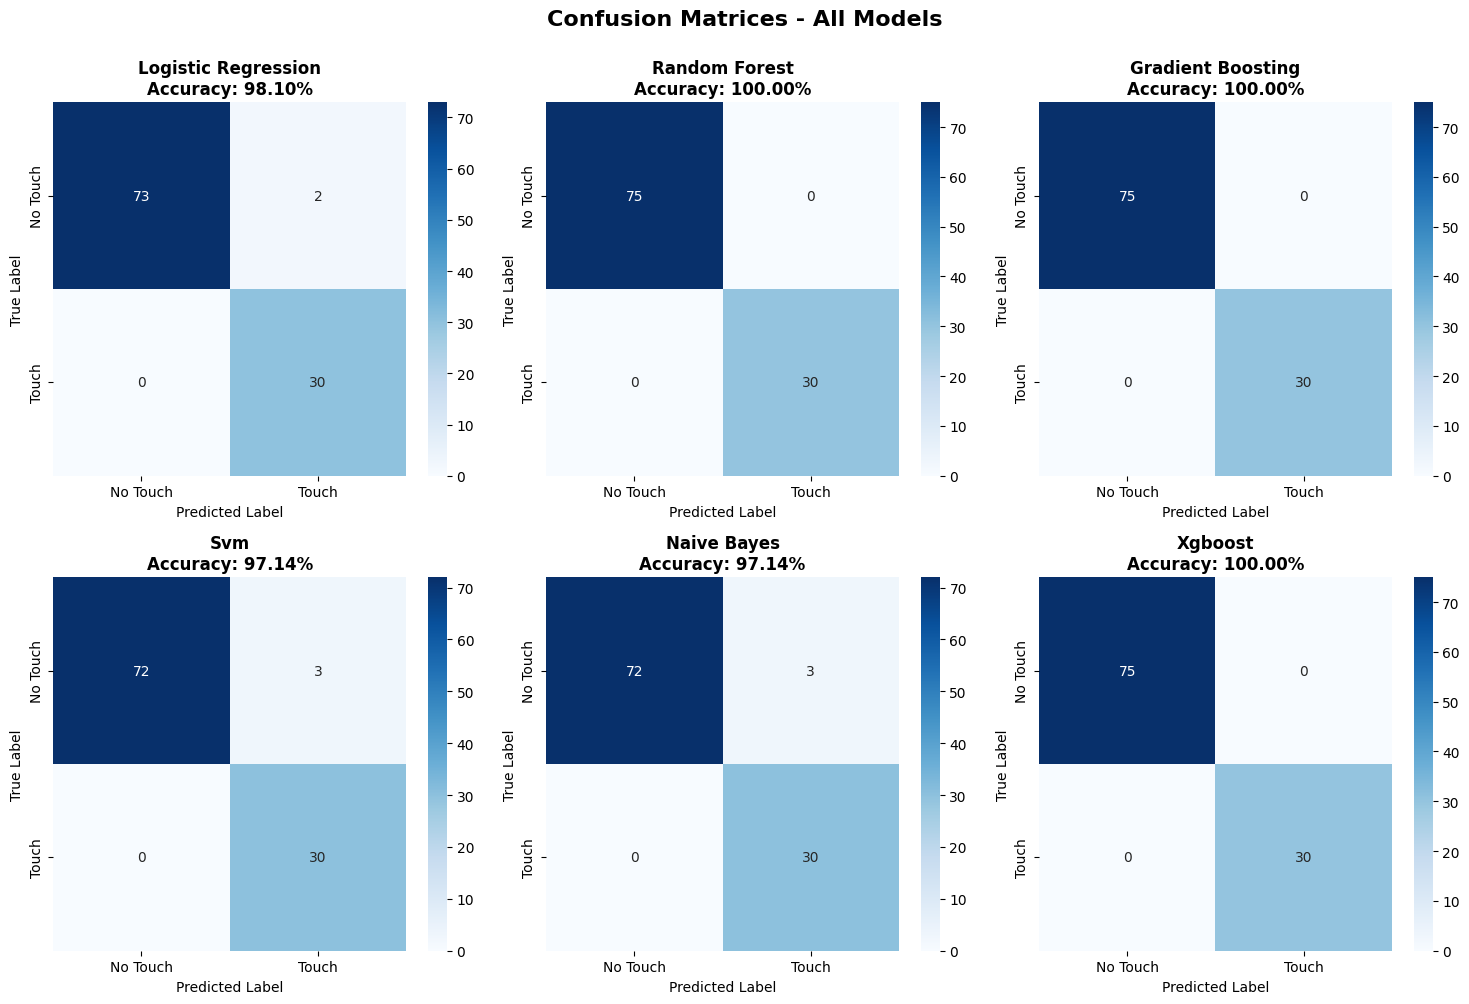

✓ Confusion matrices saved


In [11]:
# Calculate number of subplots needed
n_models = len(models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_models > 1 else [axes]

for idx, (model_name, model) in enumerate(models.items()):
    ax = axes[idx]
    
    # Get predictions
    y_pred = model.predict(X_scaled)
    
    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    
    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Touch', 'Touch'],
                yticklabels=['No Touch', 'Touch'])
    
    ax.set_title(f'{model_name.replace("_", " ").title()}\nAccuracy: {accuracy_score(y, y_pred):.2%}',
                fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

# Remove extra subplots
for idx in range(n_models, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'all_confusion_matrices.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrices saved")

## 11. ROC Curves Comparison

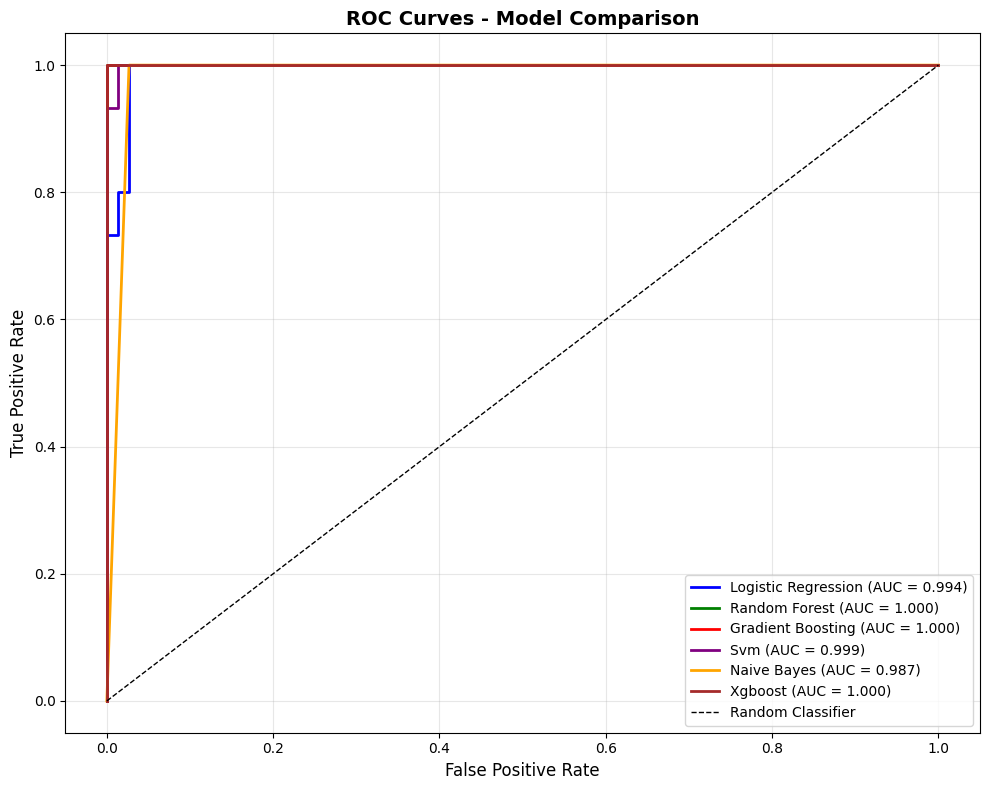

✓ ROC curves comparison saved


In [12]:
plt.figure(figsize=(10, 8))

colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

for idx, (model_name, model) in enumerate(models.items()):
    y_prob = model.predict_proba(X_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    auc = roc_auc_score(y, y_prob)
    
    plt.plot(fpr, tpr, label=f'{model_name.replace("_", " ").title()} (AUC = {auc:.3f})',
            linewidth=2, color=colors[idx % len(colors)])

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC curves comparison saved")

## 12. Feature Importance (Tree-based Models)

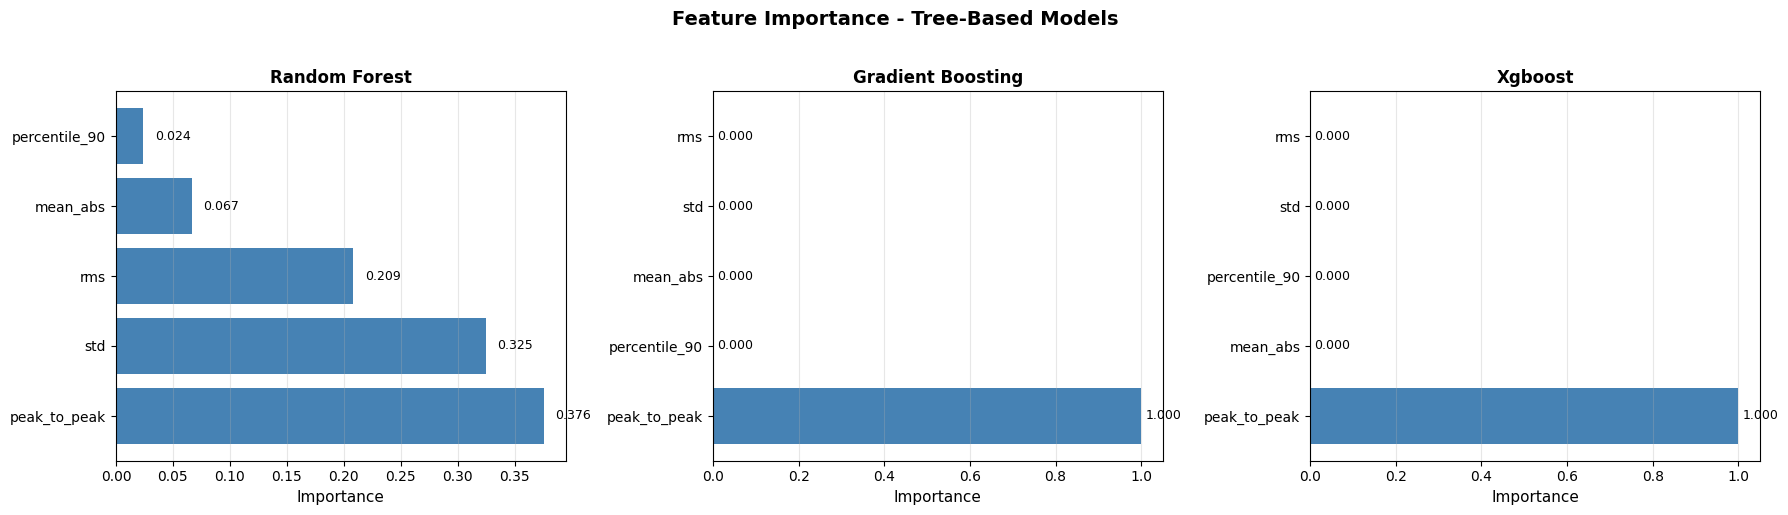

✓ Feature importance plots saved


In [13]:
# Get feature importances from tree-based models
importance_models = ['random_forest', 'gradient_boosting']
if XGBOOST_AVAILABLE:
    importance_models.append('xgboost')

fig, axes = plt.subplots(1, len(importance_models), figsize=(6 * len(importance_models), 5))
if len(importance_models) == 1:
    axes = [axes]

for idx, model_name in enumerate(importance_models):
    ax = axes[idx]
    model = models[model_name]
    
    # Get feature importances
    importances = model.feature_importances_
    
    # Sort
    indices = np.argsort(importances)[::-1]
    
    # Plot
    ax.barh(range(len(FEATURE_NAMES)), importances[indices], color='steelblue')
    ax.set_yticks(range(len(FEATURE_NAMES)))
    ax.set_yticklabels([FEATURE_NAMES[i] for i in indices])
    ax.set_xlabel('Importance', fontsize=11)
    ax.set_title(f'{model_name.replace("_", " ").title()}', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add values on bars
    for i, v in enumerate(importances[indices]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Feature Importance - Tree-Based Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature importance plots saved")

## 13. Detailed Classification Reports

In [14]:
print("="*70)
print("DETAILED CLASSIFICATION REPORTS")
print("="*70)

for model_name, model in models.items():
    print(f"\n{'─'*70}")
    print(f"{model_name.replace('_', ' ').upper()}")
    print(f"{'─'*70}")
    
    y_pred = model.predict(X_scaled)
    
    print(classification_report(y, y_pred, target_names=['No Touch', 'Touch']))
    
    # Confusion matrix details
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\nConfusion Matrix Details:")
    print(f"  True Negatives:  {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives:  {tp}")
    print(f"  Specificity: {tn/(tn+fp):.4f}")
    print(f"  Sensitivity: {tp/(tp+fn):.4f}")

print(f"\n{'='*70}\n")

DETAILED CLASSIFICATION REPORTS

──────────────────────────────────────────────────────────────────────
LOGISTIC REGRESSION
──────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    No Touch       1.00      0.97      0.99        75
       Touch       0.94      1.00      0.97        30

    accuracy                           0.98       105
   macro avg       0.97      0.99      0.98       105
weighted avg       0.98      0.98      0.98       105


Confusion Matrix Details:
  True Negatives:  73
  False Positives: 2
  False Negatives: 0
  True Positives:  30
  Specificity: 0.9733
  Sensitivity: 1.0000

──────────────────────────────────────────────────────────────────────
RANDOM FOREST
──────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    No Touch       1.00      1.00      1.00        75
       Touch       1.00      1.00      1.00        30



## 14. Model Export - Save All Models

In [ ]:
print("="*70)
print("EXPORTING MODELS")
print("="*70)

for model_name, model in models.items():
    # Package model with metadata
    model_data = {
        'model': model,
        'scaler': scaler,
        'feature_names': FEATURE_NAMES,
        'window_size': WINDOW_SIZE,
        'sample_rate': TARGET_SR,
        'training_date': datetime.now().isoformat(),
        'training_samples': len(X),
        'class_distribution': {'no_touch': int(sum(y == 0)), 'touch': int(sum(y == 1))}
    }
    
    # Save
    filepath = os.path.join(MODELS_DIR, f'{model_name}_model.pkl')
    joblib.dump(model_data, filepath)
    
    file_size = os.path.getsize(filepath) / 1024  # KB
    print(f"✓ Saved: {model_name:20s} → {filepath} ({file_size:.1f} KB)")

print(f"\n{'='*70}")
print(f"✓ ALL MODELS SAVED TO: {MODELS_DIR}/")
print(f"{'='*70}\n")

EXPORTING MODELS
✓ Saved: logistic_regression  → output\models\logistic_regression_model.pkl (1.5 KB)
✓ Saved: random_forest        → output\models\random_forest_model.pkl (89.9 KB)
✓ Saved: gradient_boosting    → output\models\gradient_boosting_model.pkl (76.1 KB)
✓ Saved: svm                  → output\models\svm_model.pkl (3.8 KB)
✓ Saved: naive_bayes          → output\models\naive_bayes_model.pkl (1.6 KB)
✓ Saved: xgboost              → output\models\xgboost_model.pkl (75.4 KB)

✓ ALL MODELS SAVED TO: output\models/



## 15. Best Model Selection

In [18]:
print("="*70)
print("BEST MODEL SELECTION")
print("="*70)

# Calculate overall scores
model_scores = {}
for model_name, model in models.items():
    y_pred = model.predict(X_scaled)
    y_prob = model.predict_proba(X_scaled)[:, 1]
    
    # Weighted score: accuracy (40%) + F1 (40%) + ROC-AUC (20%)
    score = (
        0.4 * accuracy_score(y, y_pred) +
        0.4 * f1_score(y, y_pred) +
        0.2 * roc_auc_score(y, y_prob)
    )
    model_scores[model_name] = score

# Sort by score
ranked_models = sorted(model_scores.items(), key=lambda x: x[1], reverse=True)

print("\nModel Rankings (by weighted score):\n")
for rank, (model_name, score) in enumerate(ranked_models, 1):
    emoji = '🏆' if rank == 1 else '🥈' if rank == 2 else '🥉' if rank == 3 else '  '
    print(f"{emoji} {rank}. {model_name.replace('_', ' ').title():25s} Score: {score:.4f}")

best_model_name = ranked_models[0][0]
print(f"\n{'='*70}")
print(f"🏆 RECOMMENDED MODEL: {best_model_name.replace('_', ' ').upper()}")
print(f"{'='*70}")

# Reasons
print(f"\nSelection criteria:")
print(f"  • Accuracy: 40% weight")
print(f"  • F1-Score: 40% weight")
print(f"  • ROC-AUC: 20% weight")

best_model = models[best_model_name]
y_pred_best = best_model.predict(X_scaled)
print(f"\nBest model performance:")
print(f"  • Accuracy:  {accuracy_score(y, y_pred_best):.2%}")
print(f"  • Precision: {precision_score(y, y_pred_best):.2%}")
print(f"  • Recall:    {recall_score(y, y_pred_best):.2%}")
print(f"  • F1-Score:  {f1_score(y, y_pred_best):.2%}")
print(f"  • ROC-AUC:   {roc_auc_score(y, best_model.predict_proba(X_scaled)[:, 1]):.4f}")
print(f"\n{'='*70}\n")

BEST MODEL SELECTION

Model Rankings (by weighted score):

🏆 1. Random Forest             Score: 1.0000
🥈 2. Gradient Boosting         Score: 1.0000
🥉 3. Xgboost                   Score: 1.0000
   4. Logistic Regression       Score: 0.9782
   5. Svm                       Score: 0.9693
   6. Naive Bayes               Score: 0.9669

🏆 RECOMMENDED MODEL: RANDOM FOREST

Selection criteria:
  • Accuracy: 40% weight
  • F1-Score: 40% weight
  • ROC-AUC: 20% weight

Best model performance:
  • Accuracy:  100.00%
  • Precision: 100.00%
  • Recall:    100.00%
  • F1-Score:  100.00%
  • ROC-AUC:   1.0000




## 16. Summary and Next Steps

In [22]:
print("="*70)
print("PIPELINE EXECUTION SUMMARY")
print("="*70)

print(f"\n✓ Dataset processed:")
print(f"  • Total recordings: {len(metadata)}")
print(f"  • Windows extracted: {len(X)}")
print(f"  • Features per window: {len(FEATURE_NAMES)}")

print(f"\n✓ Models trained: {len(models)}")
for model_name in models.keys():
    print(f"  • {model_name.replace('_', ' ').title()}")

print(f"\n✓ Best model: {best_model_name.replace('_', ' ').title()}")

print(f"\n✓ Files saved:")
print(f"  • Models: {MODELS_DIR}/")
print(f"  • Plots: {OUTPUT_DIR}/")
print(f"  • Comparison: {MODELS_DIR}/model_comparison.csv")

print(f"\n{'='*70}")


print("✅ PIPELINE COMPLETE!")

PIPELINE EXECUTION SUMMARY

✓ Dataset processed:
  • Total recordings: 45
  • Windows extracted: 105
  • Features per window: 5

✓ Models trained: 6
  • Logistic Regression
  • Random Forest
  • Gradient Boosting
  • Svm
  • Naive Bayes
  • Xgboost

✓ Best model: Random Forest

✓ Files saved:
  • Models: output\models/
  • Plots: output/
  • Comparison: output\models/model_comparison.csv

✅ PIPELINE COMPLETE!
